In [ ]:
import random
import pandas as pd
import numpy as np
import time
from functools import lru_cache
import sys

import time
import matplotlib.pyplot as plt

sys.setrecursionlimit(50000)

14) Seam Carving para Redimensionamento de Imagens Sensível ao Conteúdo (Ultima questão da lista de programacao dinamica)

14.1) Algoritmo de programacao dinâmica recursivo com memoizacao

14.2) Algoritmo de programacao dinamica iterativo

In [ ]:
def seam_carving_dp_memoization(E):
    n, m = len(E), len(E[0])
    memo = {}

    def seam_min_cost(i, j):
        if not (0 <= j < m):
            return float('inf')

        if i == n - 1:
            return E[i][j]

        if (i, j) in memo:
            return memo[(i, j)]

        min_cost_below = min(
            seam_min_cost(i + 1, j - 1),
            seam_min_cost(i + 1, j),
            seam_min_cost(i + 1, j + 1)
        )

        total_cost = E[i][j] + min_cost_below
        memo[(i, j)] = total_cost
        return total_cost


    costs_row0 = [seam_min_cost(0, j) for j in range(m)]

    best_cost = min(costs_row0)
    best_j = costs_row0.index(best_cost)

    path = [(0, best_j)]
    current_i, current_j = 0, best_j

    while current_i < n - 1:
        i, j = current_i, current_j
        options = []
        for dj in [-1, 0, 1]:
            nj = j + dj
            if 0 <= nj < m:
                cost = seam_min_cost(i + 1, nj)
                options.append((cost, nj))

        _, next_j = min(options)

        current_i += 1
        current_j = next_j
        path.append((current_i, current_j))

    return best_cost, path

In [ ]:
def seam_carving_iterative(E):
    n, m = len(E), len(E[0])
    dp = [[0] * m for _ in range(n)]
    path = [[-1] * m for _ in range(n)]

    for j in range(m):
        dp[0][j] = E[0][j]

    for i in range(1, n):
        for j in range(m):
            min_val = float('inf')
            prev_j = -1
            for dj in [-1, 0, 1]:
                pj = j + dj
                if 0 <= pj < m:
                    if dp[i - 1][pj] < min_val:
                        min_val = dp[i - 1][pj]
                        prev_j = pj
            dp[i][j] = E[i][j] + min_val
            path[i][j] = prev_j

    min_cost = min(dp[-1])
    end_j = dp[-1].index(min_cost)

    seam = []
    j = end_j
    for i in range(n - 1, -1, -1):
        seam.append((i, j))
        j = path[i][j]
    seam.reverse()

    return min_cost, seam

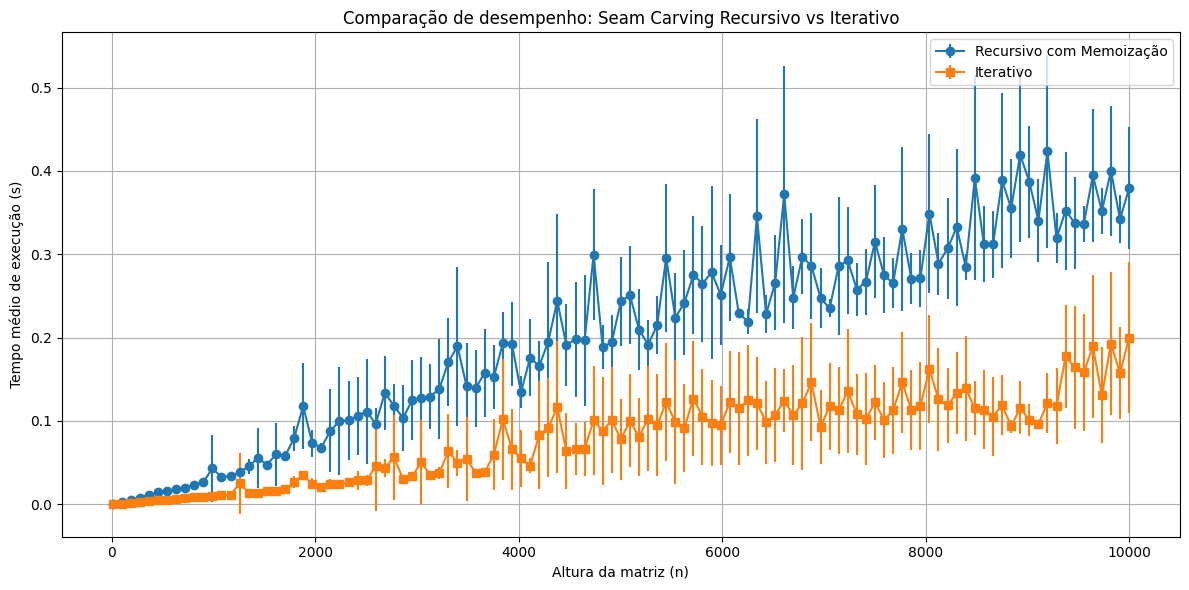

In [ ]:
def run_experiments(k=20, largura_m=30, m_trials=10):
    sizes = np.linspace(10, 10000, k, dtype=int)
    tempos_rec, tempos_it = [], []

    for n in sizes:
        t_rec, t_it = [], []
        for _ in range(m_trials):
            E = np.random.randint(0, 256, size=(n, largura_m)).tolist()

            start = time.perf_counter()
            seam_carving_dp_memoization(tuple(map(tuple, E)))
            t_rec.append(time.perf_counter() - start)

            start = time.perf_counter()
            seam_carving_iterative(E)
            t_it.append(time.perf_counter() - start)

        tempos_rec.append((np.mean(t_rec), np.std(t_rec)))
        tempos_it.append((np.mean(t_it), np.std(t_it)))

    return sizes, tempos_rec, tempos_it

def generate_grapic(sizes, tempos_rec, tempos_it, nome_arquivo="seam_carving_comparacao.csv"):
    mean_rec, std_rec = zip(*tempos_rec)
    mean_it, std_it = zip(*tempos_it)

    plt.figure(figsize=(12, 6))
    plt.errorbar(sizes, mean_rec, yerr=std_rec, label='Recursivo com Memoização', fmt='-o')
    plt.errorbar(sizes, mean_it, yerr=std_it, label='Iterativo', fmt='-s')
    plt.xlabel('Altura da matriz (n)')
    plt.ylabel('Tempo médio de execução (s)')
    plt.title('Comparação de desempenho: Seam Carving Recursivo vs Iterativo')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

k = random.randint(100, 200)
m = random.randint(10, 20)

sizes, tempos_rec, tempos_it = run_experiments(k=k, largura_m=m, m_trials=10)
generate_grapic(sizes, tempos_rec, tempos_it)